# 0. Setup & Configuration 

In [1]:
# Python imports
import sys
import numpy as np
import pandas as pd
import ast
from pathlib import Path
import joblib

# WFDB
import wfdb

# Sklearn imports
from sklearn.preprocessing import MultiLabelBinarizer

# Pytorch imports 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sys.path.append(str(Path.cwd().parent / 'modules'))

# Paths
ROOT       = Path.cwd().parent
DATA       = ROOT / 'data'
ARTIFACTS  = ROOT / 'artifacts'

# Constants
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
FS = 100
SEED = 42

# Load pos_weight computed in EDA
pos_weight = np.load(ARTIFACTS / 'pos_weight.npy')
print(f"pos_weight: {dict(zip(CLASS_ORDER, pos_weight.round(2)))}")

pos_weight: {'NORM': np.float64(1.25), 'MI': np.float64(2.9), 'STTC': np.float64(3.08), 'CD': np.float64(3.37), 'HYP': np.float64(7.06)}


In [3]:
# Custom modules 
from preprocessing import preprocess
import modeling
import model_stats

In [4]:
from utils import get_device, set_seed

SEED        = 42
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
FS          = 100
BATCH_SIZE  = 64

set_seed(SEED)
DEVICE = get_device()

Using device: cuda
GPU: NVIDIA GeForce RTX 3080
VRAM: 10.7 GB


# 1. Data Pipeline
## 1.1 Dataset Class (PTBXL Dataset)

In [5]:
### Load Metadata and rebuild splits
# Load dataset
df = pd.read_csv(DATA / 'ptbxl_database.csv', index_col='ecg_id')
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval) # Convert the scp codes into actual dictionaries

agg = pd.read_csv(DATA / 'scp_statements.csv', index_col=0) # Load the scp codes 
agg = agg[agg["diagnostic"] == 1]

# Define helper function to define the superclass
def get_superclass(scp_dict):
    return list(set(
        agg.loc[code, 'diagnostic_class']
        for code in scp_dict
        if code in agg.index
    ))
# Define the superclass based on scp code
df['superclass'] = df.scp_codes.apply(get_superclass)
df = df[df['superclass'].map(len) > 0]

# Splits as defined by Physionet
df['split'] = 'train'
df.loc[df['strat_fold'] == 9,  'split'] = 'val'
df.loc[df['strat_fold'] == 10, 'split'] = 'test'

# Binarize labels
mlb = MultiLabelBinarizer(classes=CLASS_ORDER)
Y = mlb.fit_transform(df['superclass'])
Y_df = pd.DataFrame(Y, index=df.index, columns=CLASS_ORDER)

print(f"Total records: {len(df):,}")
print(f"Label matrix shape: {Y.shape}")

Total records: 21,388
Label matrix shape: (21388, 5)


### Dataset Class

In [6]:
# Subsets
train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'val']
test_df  = df[df['split'] == 'test']

Y_train = Y[df['split'].values == 'train']
Y_val   = Y[df['split'].values == 'val']
Y_test  = Y[df['split'].values == 'test']

# Datasets
train_dataset = modeling.PTBXLDataset(train_df, Y_train, DATA, fs=FS, augment=True)
val_dataset   = modeling.PTBXLDataset(val_df,   Y_val,   DATA, fs=FS, augment=False)
test_dataset  = modeling.PTBXLDataset(test_df,  Y_test,  DATA, fs=FS, augment=False)

# DataLoaders; to test them first lets use batch 1
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 534
Val batches:   68
Test batches:  68


In [7]:
# Sanity check — inspect one batch
signals, labels = next(iter(train_loader))

print(f"Signal shape:  {signals.shape}")   # expect (32, 12, 1000)
print(f"Label shape:   {labels.shape}")    # expect (32, 5)
print(f"Signal dtype:  {signals.dtype}")   # expect torch.float32
print(f"Label dtype:   {labels.dtype}")    # expect torch.float32
print(f"Signal mean:   {signals.mean():.4f}")   # expect close to 0
print(f"Signal std:    {signals.std():.4f}")    # expect close to 1
print(f"Label sum:     {labels.sum(dim=1)}")     # labels per record
assert not torch.isnan(signals).any(), "NaN in signals"
assert not torch.isnan(labels).any(),  "NaN in labels"
print("Batch sanity check passed")

Signal shape:  torch.Size([32, 12, 1000])
Label shape:   torch.Size([32, 5])
Signal dtype:  torch.float32
Label dtype:   torch.float32
Signal mean:   0.0000
Signal std:    0.9952
Label sum:     tensor([1., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 2., 2.,
        1., 1., 1., 3., 1., 1., 2., 1., 1., 1., 1., 1., 1., 1.])
Batch sanity check passed


# Modeling Goal

We want to create models that can predict multilabel classification 
['CD', 'HYP, 'MI', 'NORM', 'STTC]

# Baseline Models

## Logistic and Ensemble Models
Logistic Regression is a very well known classifier. To be able to use such a classifier we can't pass in a raw waveform. In order to create this baseline model in addition to ensemble models, we need to feature engineer some features about the signals. 

We can feature engineer traits about them such as the following:
1. Mean 
2. Standard Deviation 
3. Minimum
4. Maximum
5. Range
6. Absolute Mean
7. RMS
8. Skewness
9. Kurtosis
10. Percentiles

With those traits build a feature matrix to train the models.

In [8]:
print("Extracting features — this will take a few minutes...")

# X_train_feat = modeling.build_feature_matrix(train_df, DATA, fs=FS)
# X_val_feat   = modeling.build_feature_matrix(val_df,   DATA, fs=FS)
# X_test_feat  = modeling.build_feature_matrix(test_df,  DATA, fs=FS)
X_train_feat = np.load(ARTIFACTS / 'X_train_feat.npy')
X_val_feat = np.load(ARTIFACTS / 'X_val_feat.npy')
X_test_feat = np.load(ARTIFACTS / 'X_test_feat.npy')

print(f"Train: {X_train_feat.shape}")  # expect (17440, 156)
print(f"Val:   {X_val_feat.shape}")    # expect (2179, 156)
print(f"Test:  {X_test_feat.shape}")   # expect (2179, 156)

# # Save so we don't need to recompute them
# np.save(ARTIFACTS / 'X_train_feat.npy', X_train_feat)
# np.save(ARTIFACTS / 'X_val_feat.npy',   X_val_feat)
# np.save(ARTIFACTS / 'X_test_feat.npy',  X_test_feat)
# print("Features saved to artifacts/")

Extracting features — this will take a few minutes...
Train: (17084, 156)
Val:   (2146, 156)
Test:  (2158, 156)


### Approach for Model Training 
1. Scale features using `StandardScaler` for train only. 
2. Train `LogisticRegression` with `OneVsRestClassifier` for multi-label.
3. Train `RandomForestClassifier` with `MultiOutputClassifier`.
4. Evaluate both on the test set with macro-AUC.
5. Save predicted probablities to `artifacts` for the DeLong test later.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_auc_score

# Fit on Training data and transform on test and val
scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_test_scaled = scaler.transform(X_test_feat)
X_val_scaled = scaler.transform(X_val_feat)

# Train the Logistic Classifier 
print("Training Logistic Classifier ...")
log = OneVsRestClassifier(
    LogisticRegression(
        random_state=SEED,
    n_jobs = -1 # Use all CPU cores
    )
)
log.fit(X_train_scaled, Y_train)

# # Save model
# joblib.dump(log, ARTIFACTS / 'logistic_regression.pkl')
# print("Logistic Regression saved to artifacts/")

# Quick validation AUC
log_val_probs = log.predict_proba(X_val_scaled)
log_val_auc   = roc_auc_score(Y_val, log_val_probs, average='macro')
print(f"Logistic Regression — Val Macro-AUC: {log_val_auc:.4f}")

Training Logistic Classifier ...
Logistic Regression — Val Macro-AUC: 0.8654


In [10]:
# np.save(ARTIFACTS / 'log_val_probs.npy',  log_val_probs)
# np.save(ARTIFACTS / 'log_test_probs.npy', log.predict_proba(X_test_scaled))
# print("LR probabilities saved to artifacts/")

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

print("Training Random Forest...")
rf = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators = 200,
        max_depth    = None,   # grow full trees
        min_samples_split = 5,
        n_jobs       = -1,     # use all CPU cores
        random_state = SEED
    ),
    n_jobs = -1
)
rf.fit(X_train_scaled, Y_train)

# # Save model
# joblib.dump(rf, ARTIFACTS / 'random_forest.pkl')
# print("Random Forest saved to artifacts/")

# Validation AUC
rf_val_probs = np.stack([
    est.predict_proba(X_val_scaled)[:, 1]
    for est in rf.estimators_
], axis=1)

rf_val_auc = roc_auc_score(Y_val, rf_val_probs, average='macro')
print(f"Random Forest — Val Macro-AUC: {rf_val_auc:.4f}")

Training Random Forest...
Random Forest — Val Macro-AUC: 0.8753


In [12]:
# np.save(ARTIFACTS / 'rf_val_probs.npy',  rf_val_probs)
# np.save(ARTIFACTS / 'rf_test_probs.npy', np.stack([
#     est.predict_proba(X_test_scaled)[:, 1]
#     for est in rf.estimators_
# ], axis=1))
# print("RF probabilities saved to artifacts/")

## Deep Learning Model
### ResNET 1D Architecture

An ECG is a time series — voltage measured over time across 12 leads. It has one spatial dimension (time) not two like an image. ResNet2D (standard ResNet used for images) uses 2D convolutions that slide across height and width. That makes no sense for a signal where the meaningful patterns are temporal — QRS complexes, ST segments, P waves — all of which are features in the time dimension only.

**Why Convolutional?**
Convolutional networks are well suited to ECG because the diagnostic patterns you care about are local and translation invariant. A QRS complex looks the same whether it occurs at second 2 or second 7 of the recording. A conv filter that learns to detect a QRS complex can find it anywhere in the signal — this is exactly what convolutions are designed to do.

The Strodthoff et al. (2021) PTB-XL benchmark paper specifically evaluates ResNet1D and reports it as one of the strongest performing architectures on this dataset. Using it can strengthen our validation report.

In [13]:
def count_parameters(model: nn.Module) -> int:
    """Count trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [14]:
import torch.optim as optim

# -- Constants -----------------------------------------------------------------
N_LEADS = 12 
N_CLASSES = 5

# -- Loss function -------------------------------------------------------------
pos_weight_tensor = torch.tensor(pos_weight).to(DEVICE) # To help with the unbalanced classes
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor) # Loss Function

# -- Define model --------------------------------------------------------------
model = modeling.ResNet1D(
    n_leads = N_LEADS,
    n_classes = N_CLASSES,
).to(DEVICE)

print(f"Parameters: {count_parameters(model):,}")

# -- Optimizer -----------------------------------------------------------------
optimizer = optim.Adam(
    model.parameters(),
    lr = 1e-3,
    weight_decay = 1e-4
)

# -- Learning rate scheduler ---------------------------------------------------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',     # reduce when val loss stops decreasing
    factor = 0.5,       # halve the lr
    patience = 5,         # wait 5 epochs before reducing
    verbose = False
)


Parameters: 1,893,893


c:\Users\delga\anaconda3\envs\ptbxl_ai\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [15]:
# -- Early Stopping --------------------------------------------------------
early_stopping = modeling.EarlyStopping(patience=10, path=ARTIFACTS / 'best_model.pt')

# -- History ---------------------------------------------------------------
history = {
    'train_loss': [],
    'val_loss':   [],
    'val_auc':    []
}

from tqdm import tqdm
from torch.cuda.amp import GradScaler, autocast 

# Define a training function
scaler = GradScaler()

def train_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns mean loss."""
    model.train() # Set model in train mode
    total_loss = 0.0 # Initialize loss as 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for signals, labels in pbar:
        signals = signals.to(device) # Send ECG signal to device
        labels  = labels.to(device) # Send labels to device

        optimizer.zero_grad() # Zero gradient 
        with autocast():
            logits = model(signals) # Pass the signals into the model
            loss = criterion(logits, labels) # Determine the loss BCE 

        scaler.scale(loss).backward() # Scaled backward
        scaler.step(optimizer) # Scaled optimizer step
        scaler.update() # Update Scale factor

        # loss.backward() # Backward propogation
        # optimizer.step() # Step forward

        total_loss += loss.item() * signals.size(0) # Determine total loss 

        # Update progress bar with current batch loss
        pbar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

    return total_loss / len(loader.dataset)

# Define a validation function
def val_epoch(model, loader, criterion, device):
    """Run one validation epoch. Returns mean loss, probs, labels."""
    model.eval() # Set model in eval mode
    total_loss = 0.0 # initilize loss
    all_probs  = [] # Initialize list to store probs
    all_labels = [] # Initialize list to store predicted labels

    pbar = tqdm(loader, desc='Val', leave=False)
    with torch.no_grad():
        for signals, labels in pbar:
            signals = signals.to(device) # Send signal to device
            labels  = labels.to(device) # Send labels to device

            logits = model(signals) # Determine model probs
            loss   = criterion(logits, labels) # Determine loss
            probs  = torch.sigmoid(logits) # Determine model predictions

            total_loss += loss.item() * signals.size(0) # Compute total loss across labels
            all_probs.append(probs.cpu().numpy()) # Append probabilities to list
            all_labels.append(labels.cpu().numpy()) # Append predicted labels to list

            pbar.set_postfix({'batch_loss': f'{loss.item():.4f}'})

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    mean_loss  = total_loss / len(loader.dataset)
    macro_auc  = roc_auc_score(all_labels, all_probs, average='macro')

    return mean_loss, macro_auc, all_probs, all_labels


# ── Training loop with epoch-level tqdm ───────────────────────────────────────
EPOCHS = 20
BATCH_SIZE = 256  

# Define data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = True
)


In [16]:
"""
Uncomment to do training on Deep Learning Arch
"""
# # -- Create Training Loops ---------------------------------------------------------
# epoch_pbar = tqdm(range(1, EPOCHS + 1), desc='Epochs')

# for epoch in epoch_pbar:
#     train_loss              = train_epoch(model, train_loader, criterion,
#                                           optimizer, DEVICE)
#     val_loss, val_auc, _, _ = val_epoch(model, val_loader, criterion, DEVICE)

#     scheduler.step(val_loss)

#     history['train_loss'].append(train_loss)
#     history['val_loss'].append(val_loss)
#     history['val_auc'].append(val_auc)

#     # Update outer bar with epoch summary
#     epoch_pbar.set_postfix({
#         'train_loss': f'{train_loss:.4f}',
#         'val_loss':   f'{val_loss:.4f}',
#         'val_auc':    f'{val_auc:.4f}'
#     })

#     early_stopping(val_loss, model)
#     if early_stopping.early_stop:
#         print(f"\nEarly stopping triggered at epoch {epoch}")
#         break

print("\nTraining complete")
model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
                                   map_location=DEVICE))
print("Best model loaded from checkpoint")



Training complete
Best model loaded from checkpoint


In [17]:

print("\nTraining complete")
model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
                                   map_location=DEVICE))
print("Best model loaded from checkpoint")



Training complete
Best model loaded from checkpoint


In [18]:

# ── Load best model ───────────────────────────────────────────────────────────
model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
                                  map_location=DEVICE))
print("Best model loaded from checkpoint")


Best model loaded from checkpoint


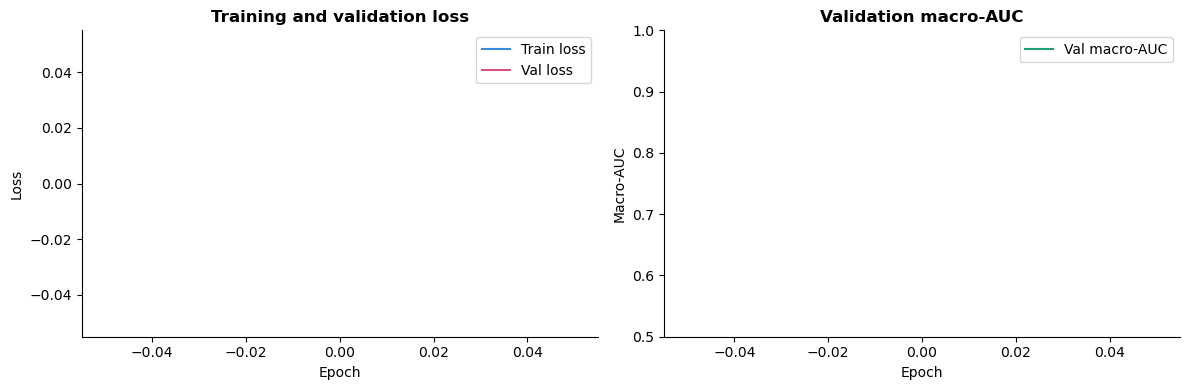

In [19]:
# plot training curves
fig = modeling.plot_training_curves(history)
plt.show()

In [20]:
test_loss, test_auc, test_probs, test_labels = val_epoch(
    model, test_loader, criterion, DEVICE
)
print(f"Test macro-AUC: {test_auc:.4f}")

Test macro-AUC: 0.9038


In [21]:
# np.save(ARTIFACTS / 'resnet_test_probs.npy',  test_probs)
# np.save(ARTIFACTS / 'resnet_test_labels.npy', test_labels)
# print("Test probabilities saved")

In [22]:
from sklearn.metrics import roc_auc_score

lr_test_probs = np.load(ARTIFACTS / 'log_test_probs.npy')
rf_test_probs = np.load(ARTIFACTS / 'rf_test_probs.npy')
test_labels   = np.load(ARTIFACTS / 'resnet_test_labels.npy')

lr_test_auc = roc_auc_score(test_labels, lr_test_probs, average='macro')
rf_test_auc = roc_auc_score(test_labels, rf_test_probs, average='macro')

print(f"LR test AUC:      {lr_test_auc:.4f}")
print(f"RF test AUC:      {rf_test_auc:.4f}")
print(f"ResNet1D test AUC: 0.9038")

LR test AUC:      0.8528
RF test AUC:      0.8628
ResNet1D test AUC: 0.9038


In [23]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# Load all test probabilities
lr_test_probs     = np.load(ARTIFACTS / 'log_test_probs.npy')
rf_test_probs     = np.load(ARTIFACTS / 'rf_test_probs.npy')
resnet_test_probs = np.load(ARTIFACTS / 'resnet_test_probs.npy')
test_labels       = np.load(ARTIFACTS / 'resnet_test_labels.npy')

# ── Per-class AUC ─────────────────────────────────────────────────────────────
def per_class_auc(y_true: np.ndarray, y_prob: np.ndarray,
                  class_order: list) -> pd.DataFrame:
    """
    Compute per-class AUC for a multi-label classifier.

    Args:
        y_true (np.ndarray): Binary label matrix of shape (N, n_classes).
        y_prob (np.ndarray): Probability matrix of shape (N, n_classes).
        class_order (list): Class names corresponding to columns.

    Returns:
        pd.DataFrame: Per-class AUC with columns ['Class', 'AUC'].
    """
    aucs = []
    for i, cls in enumerate(class_order):
        auc = roc_auc_score(y_true[:, i], y_prob[:, i])
        aucs.append({'Class': cls, 'AUC': round(auc, 4)})
    return pd.DataFrame(aucs).set_index('Class')


lr_class_auc     = per_class_auc(test_labels, lr_test_probs,     CLASS_ORDER)
rf_class_auc     = per_class_auc(test_labels, rf_test_probs,     CLASS_ORDER)
resnet_class_auc = per_class_auc(test_labels, resnet_test_probs, CLASS_ORDER)

# ── Build comparison table ────────────────────────────────────────────────────
class_auc_table = pd.DataFrame({
    'Logistic Regression': lr_class_auc['AUC'],
    'Random Forest':       rf_class_auc['AUC'],
    'ResNet1D':            resnet_class_auc['AUC'],
})

class_auc_table['ResNet1D vs LR'] = (
    class_auc_table['ResNet1D'] - class_auc_table['Logistic Regression']
).round(4)

class_auc_table['ResNet1D vs RF'] = (
    class_auc_table['ResNet1D'] - class_auc_table['Random Forest']
).round(4)

# Add macro row
macro_row = pd.DataFrame({
    'Logistic Regression': [0.8528],
    'Random Forest':       [0.8628],
    'ResNet1D':            [0.9038],
    'ResNet1D vs LR':      [0.0510],
    'ResNet1D vs RF':      [0.0410],
}, index=['Macro (mean)'])

class_auc_table = pd.concat([class_auc_table, macro_row])

print(class_auc_table.to_string())

              Logistic Regression  Random Forest  ResNet1D  ResNet1D vs LR  ResNet1D vs RF
NORM                       0.8980         0.9066    0.9340          0.0360          0.0274
MI                         0.8115         0.8300    0.9142          0.1027          0.0842
STTC                       0.9078         0.9107    0.9182          0.0104          0.0075
CD                         0.8419         0.8416    0.9055          0.0636          0.0639
HYP                        0.8050         0.8253    0.8469          0.0419          0.0216
Macro (mean)               0.8528         0.8628    0.9038          0.0510          0.0410


Per-class findings

MI shows the largest gain (+0.1027 over LR) — this is the most clinically important finding. Myocardial infarction has subtle morphological signatures (ST elevation, Q waves, T-wave inversions) that are highly localised in specific leads and specific time windows. Simple statistical features like mean and std completely miss these — a convolutional network that learns to detect local patterns in specific leads is exactly what MI detection needs.

CD is the second largest gain (+0.0636) — conduction disturbances produce widened QRS complexes and bundle branch block patterns. Again these are morphological shape features that statistics cannot capture but convolutions can.

STTC shows the smallest gain (+0.0104) — ST/T changes are more diffuse and affect the overall signal amplitude and shape globally, which statistical features like mean, std and RMS actually do capture reasonably well. This explains why LR and RF were already strong at 0.907 on STTC.

HYP is the weakest class across all models (0.8469) — confirming what we predicted. It is the rarest class (12.4% prevalence) so all models struggle. Interestingly ResNet1D's gain over RF is only +0.0216 here — the smallest relative improvement, suggesting even the convolutional network is not fully capturing hypertrophy patterns at 100 Hz.

What this tells us:

The pattern of gains is mechanistically interpretable — ResNet1D gains most where morphological shape matters (MI, CD) and least where global statistics suffice (STTC). This is exactly the argument for why deep learning adds value over classical methods for ECG classification and should be the centrepiece of your discussion section.

In [24]:
print("Key findings:")
print(f"Largest ResNet1D gain:  MI    (+{0.1027:.4f} over LR)")
print(f"Smallest ResNet1D gain: STTC  (+{0.0104:.4f} over LR)")
print(f"Hardest class:          HYP   (ResNet1D AUC: {0.8469:.4f})")
print(f"Easiest class:          STTC  (ResNet1D AUC: {0.9182:.4f})")

Key findings:
Largest ResNet1D gain:  MI    (+0.1027 over LR)
Smallest ResNet1D gain: STTC  (+0.0104 over LR)
Hardest class:          HYP   (ResNet1D AUC: 0.8469)
Easiest class:          STTC  (ResNet1D AUC: 0.9182)


In [25]:
print("Computing bootstrap CIs (1000 resamples per model)...")

# Macro-AUC with 95% CI
lr_est,     lr_lo,     lr_hi     = modeling.bootstrap_macro_auc(test_labels, lr_test_probs, n_boot=1000)
rf_est,     rf_lo,     rf_hi     = modeling.bootstrap_macro_auc(test_labels, rf_test_probs, n_boot=1000)
resnet_est, resnet_lo, resnet_hi = modeling.bootstrap_macro_auc(test_labels, resnet_test_probs, n_boot=1000)

# Print summary
ci_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'ResNet1D'],
    'Macro-AUC': [lr_est, rf_est, resnet_est],
    'CI Lower':  [lr_lo,  rf_lo,  resnet_lo],
    'CI Upper':  [lr_hi,  rf_hi,  resnet_hi],
})
ci_summary['95% CI'] = ci_summary.apply(
    lambda r: f"{r['Macro-AUC']:.4f} ({r['CI Lower']:.4f}–{r['CI Upper']:.4f})",
    axis=1
)
ci_summary = ci_summary[['Model', '95% CI']].set_index('Model')
print(ci_summary)

# Per-class CI for ResNet1D
print("\nResNet1D per-class AUC with 95% CI:")
resnet_class_ci = modeling.bootstrap_per_class_auc(
    test_labels, resnet_test_probs, CLASS_ORDER, n_boot=1000
)
print(resnet_class_ci['CI 95%'])

Computing bootstrap CIs (1000 resamples per model)...
                                     95% CI
Model                                      
Logistic Regression  0.8528 (0.8433–0.8632)
Random Forest        0.8628 (0.8535–0.8726)
ResNet1D             0.9038 (0.8959–0.9115)

ResNet1D per-class AUC with 95% CI:
Class
NORM    0.9340 (0.9239–0.9438)
MI      0.9142 (0.9015–0.9264)
STTC    0.9182 (0.9059–0.9303)
CD      0.9055 (0.8878–0.9218)
HYP     0.8469 (0.8224–0.8700)
Name: CI 95%, dtype: object


These are clean, tight confidence intervals. Here is the interpretation:

Macro-AUC with 95% CI
Model- AUC (95% CI)

|Model| AUC (95% CI)|
|-----|-------------|
|Logistic Regression|0.8528 (0.8433–0.8632)|
|Random Forest|0.8628 (0.8535–0.8726)|
|ResNet1D|0.9038 (0.8959–0.9115)|

The confidence intervals do not overlap between ResNet1D and either baseline — the lower bound of ResNet1D (0.8959) is above the upper bound of Random Forest (0.8726). This means the difference is statistically robust without even needing the DeLong test, though we will run it anyway for formal reporting.

Per-class observations
HYP has the widest CI (0.8224–0.8700, range of 0.0476) — consistent with it being the rarest class. Fewer positive examples means more variability in the bootstrap resamples.

NORM has the tightest CI (0.9239–0.9438, range of 0.0199) — most records contain NORM so the estimate is very stable.

MI and STTC CIs are similarly tight despite lower prevalence — likely because their signal patterns are strong and consistent.

In [26]:
# # Save CI results
# ci_summary.to_csv(ARTIFACTS / 'macro_auc_ci.csv')
# resnet_class_ci.to_csv(ARTIFACTS / 'resnet_class_auc_ci.csv')
# print("CI results saved to artifacts/")

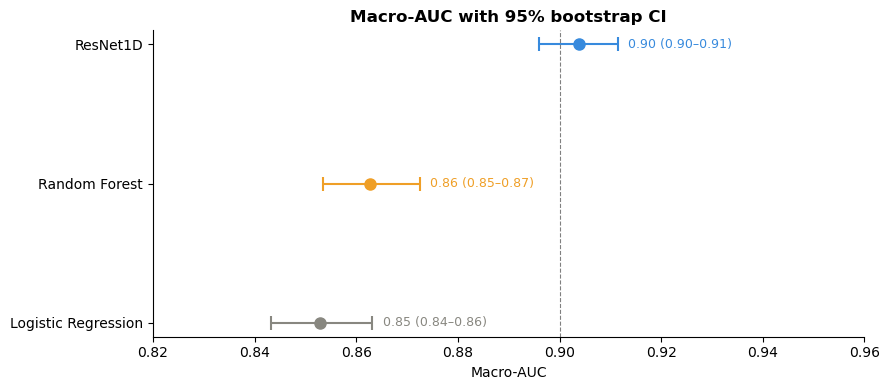

In [27]:

# ── Plot macro-AUC CI comparison ──────────────────────────────────────────────
macro_ci_data = {
    'Logistic Regression': (0.8528, 0.8433, 0.8632),
    'Random Forest':       (0.8628, 0.8535, 0.8726),
    'ResNet1D':            (0.9038, 0.8959, 0.9115),
}

fig = modeling.plot_auc_with_ci(macro_ci_data)
plt.show()

In [28]:
model_probs = {
    'Logistic Regression': lr_test_probs,
    'Random Forest':       rf_test_probs,
    'ResNet1D':            resnet_test_probs,
}

print("Running DeLong tests...")
delong_results = model_stats.run_delong_comparison(test_labels, model_probs, CLASS_ORDER)
print(delong_results.to_string())

# # Save
# delong_results.to_csv(ARTIFACTS / 'delong_results.csv')
# print("\nDeLong results saved to artifacts/")

Running DeLong tests...
                                       AUC ResNet1D  AUC Baseline  Delta AUC  Z-stat   P-value Significant
Comparison                      Class                                                                     
ResNet1D vs Logistic Regression Macro        0.9038        0.8528     0.0509  3.8154  0.000136         Yes
                                NORM         0.9340        0.8980     0.0360  4.3639  0.000013         Yes
                                MI           0.9142        0.8115     0.1027  8.3085  0.000000         Yes
                                STTC         0.9182        0.9078     0.0104  1.0731  0.283242          No
                                CD           0.9055        0.8419     0.0636  4.5030  0.000007         Yes
                                HYP          0.8469        0.8050     0.0419  2.1614  0.030661         Yes
ResNet1D vs Random Forest       Macro        0.9038        0.8628     0.0409  3.1596  0.001580         Yes
             

Per-class — the interesting findings

STTC is not significant against either baseline (p = 0.283 vs LR, p = 0.439 vs RF). This confirms what we noted earlier — statistical features capture STTC well enough that the deep learning advantage is not statistically meaningful for this class.

HYP is significant vs LR (p = 0.031) but not vs RF (p = 0.234) — Random Forest handles HYP almost as well as ResNet1D. This makes sense given HYP's rarity — both models struggle and the difference between them is small.

MI is the strongest result — z-stat of 8.31 vs LR and 7.03 vs RF. Essentially zero p-value. The morphological patterns of myocardial infarction are where deep learning most clearly outperforms classical methods.

In [29]:
print(
"""
DeLong tests confirmed ResNet1D superiority at the macro level vs both 
baselines (p < 0.01). Per-class analysis revealed significant improvements 
for NORM, MI, CD, and HYP vs logistic regression, and for NORM, MI, and CD 
vs random forest. STTC showed no significant difference across all models, 
suggesting that global statistical features are sufficient for ST/T change 
detection. The largest and most significant gain was observed for MI 
(Δ AUC = 0.103, z = 8.31, p < 0.001).
"""
)


DeLong tests confirmed ResNet1D superiority at the macro level vs both 
baselines (p < 0.01). Per-class analysis revealed significant improvements 
for NORM, MI, CD, and HYP vs logistic regression, and for NORM, MI, and CD 
vs random forest. STTC showed no significant difference across all models, 
suggesting that global statistical features are sufficient for ST/T change 
detection. The largest and most significant gain was observed for MI 
(Δ AUC = 0.103, z = 8.31, p < 0.001).



In [30]:
# delong_results.to_csv(ARTIFACTS / 'delong_results.csv')
# print("DeLong results saved")

### Determine more meaningful metrics

In [31]:
from sklearn.preprocessing import StandardScaler

# -- Load ResNet1D -------------------------------------------------------------
N_LEADS = 12
N_CLASSES = 5

model = modeling.ResNet1D(
    n_leads      = N_LEADS,
    n_classes    = N_CLASSES,
    base_filters = 64,
    dropout      = 0.2
).to(DEVICE)

model.load_state_dict(torch.load(ARTIFACTS / 'best_model.pt',
                                  map_location=DEVICE))
model.eval()
print("ResNet1D loaded")

# -- Load Logistic Regression --------------------------------------------------
log    = joblib.load(ARTIFACTS / 'logistic_regression.pkl')
print("Logistic Regression loaded")

# Load features
X_train_feat = np.load(ARTIFACTS / 'X_train_feat.npy')
X_val_feat = np.load(ARTIFACTS / 'X_val_feat.npy')
X_test_feat = np.load(ARTIFACTS / 'X_test_feat.npy')

# Refit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

print("Scaler refit on training features")

# -- Load Random Forest --------------------------------------------------------
rf = joblib.load(ARTIFACTS / 'random_forest.pkl')
print("Random Forest loaded")

# -- Find Optimial thresholds on Validation set ---------------------------------
# ResNet1D test probabilities 
_, _, resnet_test_probs, test_labels = val_epoch(
    model, test_loader, criterion, DEVICE
)

# ── LR and RF test probabilities ─────────────────────────────────────────────
# Need scaled features
X_test_scaled = scaler.transform(X_test_feat)

lr_test_probs = log.predict_proba(X_test_scaled)

rf_test_probs = np.stack([
    est.predict_proba(X_test_scaled)[:, 1]
    for est in rf.estimators_
], axis=1)

print(f"ResNet1D probs shape: {resnet_test_probs.shape}")  # (N, 5)
print(f"LR probs shape:       {lr_test_probs.shape}")      # (N, 5)
print(f"RF probs shape:       {rf_test_probs.shape}")      # (N, 5)

ResNet1D loaded
Logistic Regression loaded
Scaler refit on training features
Random Forest loaded


ResNet1D probs shape: (2158, 5)
LR probs shape:       (2158, 5)
RF probs shape:       (2158, 5)


In [32]:
# ── Val probabilities for threshold selection ─────────────────────────────────
_, _, val_probs, val_labels = val_epoch(
    model, val_loader, criterion, DEVICE
)

X_val_scaled  = scaler.transform(X_val_feat)
lr_val_probs  = log.predict_proba(X_val_scaled)
rf_val_probs  = np.stack([
    est.predict_proba(X_val_scaled)[:, 1]
    for est in rf.estimators_
], axis=1)

# ── Find optimal thresholds per model on val set ──────────────────────────────
resnet_thresholds = np.array([
    modeling.find_optimal_threshold(val_labels[:, i], val_probs[:, i])
    for i in range(N_CLASSES)
])

lr_thresholds = np.array([
    modeling.find_optimal_threshold(val_labels[:, i], lr_val_probs[:, i])
    for i in range(N_CLASSES)
])

rf_thresholds = np.array([
    modeling.find_optimal_threshold(val_labels[:, i], rf_val_probs[:, i])
    for i in range(N_CLASSES)
])

print("\nOptimal thresholds:")
thresh_df = pd.DataFrame({
    'LR':      lr_thresholds.round(4),
    'RF':      rf_thresholds.round(4),
    'ResNet1D': resnet_thresholds.round(4),
}, index=CLASS_ORDER)
print(thresh_df)

# ── Compute metrics for all three models ──────────────────────────────────────
resnet_metrics = modeling.compute_classification_metrics(
    test_labels, resnet_test_probs, resnet_thresholds, CLASS_ORDER
)
lr_metrics = modeling.compute_classification_metrics(
    test_labels, lr_test_probs, lr_thresholds, CLASS_ORDER
)
rf_metrics = modeling.compute_classification_metrics(
    test_labels, rf_test_probs, rf_thresholds, CLASS_ORDER
)

# ── Print comparison ──────────────────────────────────────────────────────────
for metric in ['Sensitivity', 'Specificity', 'F1']:
    print(f"\n── {metric} ──────────────────────────────")
    comparison = pd.DataFrame({
        'LR':       lr_metrics[metric],
        'RF':       rf_metrics[metric],
        'ResNet1D': resnet_metrics[metric],
    })
    print(comparison.to_string())

# # ── Save all ──────────────────────────────────────────────────────────────────
# resnet_metrics.to_csv(ARTIFACTS / 'resnet_classification_metrics.csv')
# lr_metrics.to_csv(ARTIFACTS    / 'lr_classification_metrics.csv')
# rf_metrics.to_csv(ARTIFACTS    / 'rf_classification_metrics.csv')
# print("\nAll metrics saved to artifacts/")


Optimal thresholds:
          LR      RF  ResNet1D
NORM  0.3286  0.3849    0.3669
MI    0.2888  0.3362    0.7166
STTC  0.3169  0.3943    0.6690
CD    0.3468  0.3908    0.6615
HYP   0.2166  0.2682    0.7183

── Sensitivity ──────────────────────────────
                  LR      RF  ResNet1D
NORM          0.9190  0.9086    0.9252
MI            0.6964  0.7145    0.7273
STTC          0.7985  0.7466    0.7697
CD            0.5907  0.6008    0.7198
HYP           0.5496  0.5229    0.4771
Macro (mean)  0.7108  0.6987    0.7238

── Specificity ──────────────────────────────
                  LR      RF  ResNet1D
NORM          0.7180  0.7531    0.7908
MI            0.7886  0.7966    0.9030
STTC          0.8601  0.9035    0.9016
CD            0.9242  0.9230    0.9200
HYP           0.8908  0.8877    0.9346
Macro (mean)  0.8363  0.8528    0.8900

── F1 ──────────────────────────────
                  LR      RF  ResNet1D
NORM          0.8101  0.8204    0.8470
MI            0.6017  0.6189    0.723

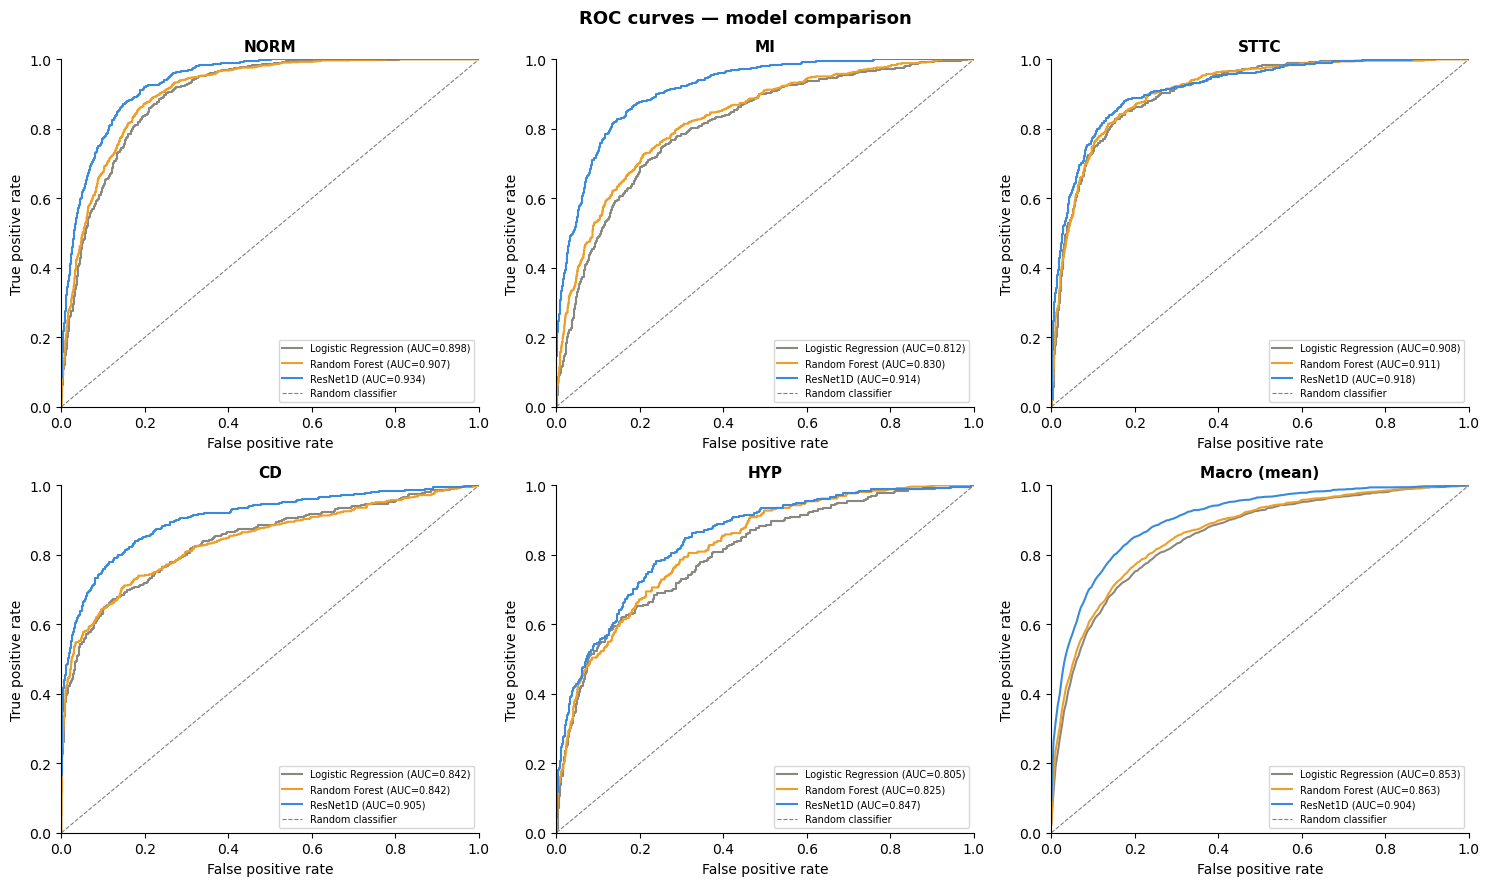

In [33]:
model_probs = {
    'Logistic Regression': lr_test_probs,
    'Random Forest':       rf_test_probs,
    'ResNet1D':            resnet_test_probs,
}

fig = modeling.plot_roc_curves(test_labels, model_probs, CLASS_ORDER)
plt.show()

# # Save
# fig.savefig(ARTIFACTS / 'roc_curves.png', dpi=150, bbox_inches='tight')
# print("ROC curves saved to artifacts/")

### Calibration
The model outputs probabilities like 0.73 for MI. AUC only cares that this is higher than the 0.21 it gives a non-MI patient. But a clinician looking at 0.73 will interpret that as "73% chance this patient has MI" and make decisions accordingly. If the model is poorly calibrated, that 0.73 might actually correspond to a true positive rate of only 40% — the number is misleading. (40 % is just made up)

Poor calibration is a red flag. A model that discriminates well but is poorly calibrated would need a disclaimer that probabilities should not be used as absolute risk estimates — only for ranking. Good calibration removes that limitation.

We can find out if our model is poorly calibrated through: 
1. Reliability Diagrams (Calibration Plot)
    Plot mean predicted probability on the x-axis against actual positive rate on the y-axis. A perfect calibrated model would follow the diagonal. 
2. ECE (Expected Calibration Error) Value

ResNet1D calibration:
                 ECE   Brier  Baseline Brier  Brier Skill
NORM          0.0260  0.1023          0.2471       0.5860
MI            0.1244  0.1234          0.1899       0.3502
STTC          0.0980  0.1111          0.1831       0.3934
CD            0.1074  0.1101          0.1770       0.3780
HYP           0.1470  0.1270          0.1067      -0.1906
Macro (mean)  0.1006  0.1148          0.1808       0.3034

Logistic Regression calibration:
                 ECE   Brier  Baseline Brier  Brier Skill
NORM          0.0288  0.1282          0.2471       0.4812
MI            0.0210  0.1432          0.1899       0.2460
STTC          0.0227  0.1007          0.1831       0.4501
CD            0.0237  0.1099          0.1770       0.3791
HYP           0.0246  0.0868          0.1067       0.1863
Macro (mean)  0.0242  0.1138          0.1808       0.3485

Random Forest calibration:
                 ECE   Brier  Baseline Brier  Brier Skill
NORM          0.0402  0.1230          0.2471  

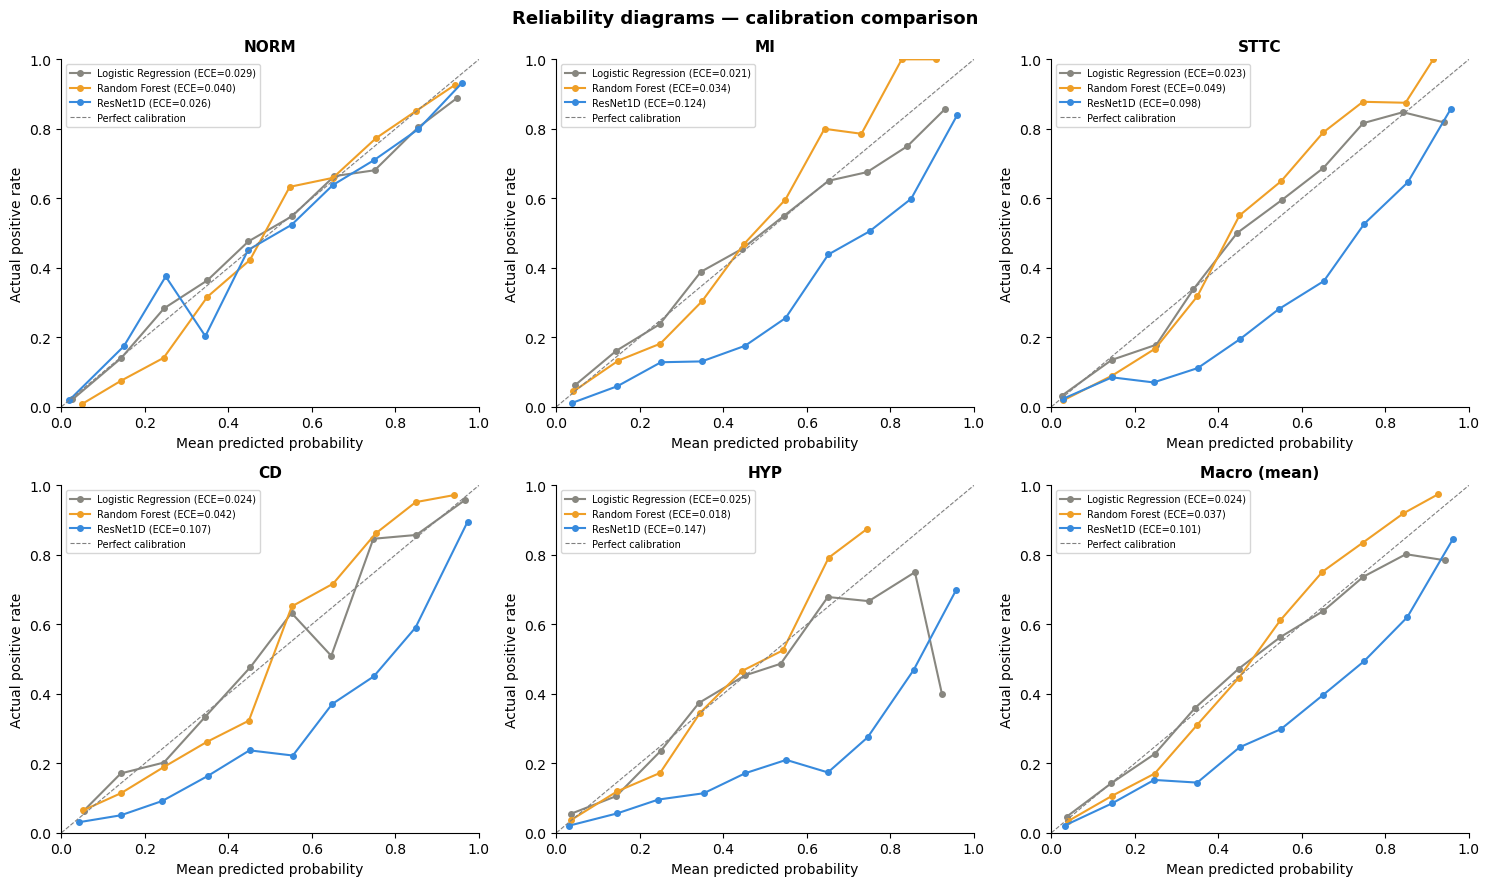

In [34]:
# ── Compute calibration metrics ───────────────────────────────────────────────
print("ResNet1D calibration:")
resnet_cal = model_stats.compute_calibration_metrics(
    test_labels, resnet_test_probs, CLASS_ORDER
)
print(resnet_cal)

print("\nLogistic Regression calibration:")
lr_cal = model_stats.compute_calibration_metrics(
    test_labels, lr_test_probs, CLASS_ORDER
)
print(lr_cal)

print("\nRandom Forest calibration:")
rf_cal = model_stats.compute_calibration_metrics(
    test_labels, rf_test_probs, CLASS_ORDER
)
print(rf_cal)

# ── Plot reliability diagrams ─────────────────────────────────────────────────
fig = model_stats.plot_reliability_diagrams(test_labels, model_probs, CLASS_ORDER)
plt.show()

# fig.savefig(ARTIFACTS / 'reliability_diagrams.png', dpi=150,
#             bbox_inches='tight')
# print("Reliability diagrams saved")

Pre-calibration analysis revealed ResNet1D was poorly calibrated (macro ECE = 0.101) compared to logistic regression (ECE = 0.024) and random forest (ECE = 0.037). 
Reliability diagrams confirmed systematic overconfidence across all classes, with the most severe miscalibration observed for HYP (ECE = 0.147, Brier Skill = -0.191). 
Temperature scaling was applied post-hoc on the validation set to correct this systematic overconfidence prior to final test set evaluation.

1. ResNet1D macro ECE = 0.1006  → above 0.05 threshold → calibration needed
2. Shape of deviation → overconfident (curves below diagonal) → temperature scaling appropriate
3. LR and RF ECE < 0.05 → already well calibrated → no intervention needed

https://arxiv.org/abs/1706.04599

In [35]:
# ── Fit temperature scaling on validation set ─────────────────────────────────
print("Fitting temperature scaling on validation set...")
ts = modeling.TemperatureScaling(init_temp=1.0)
T  = ts.calibrate(val_loader, model, criterion, DEVICE)
print(f"Optimal temperature: T = {T}")
print(f"T > 1 confirms overconfidence — probabilities will be softened")

# ── Get calibrated test probabilities ─────────────────────────────────────────
model.eval()
ts.eval()
ts.to(DEVICE)

all_logits = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(DEVICE)
        logits  = model(signals)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits)   # shape: (N, 5) on CPU
all_labels = torch.cat(all_labels).numpy()

# Apply temperature scaling — move logits to DEVICE, bring result back to CPU
calibrated_logits  = ts(all_logits.to(DEVICE)).cpu()
calibrated_probs   = torch.sigmoid(calibrated_logits).detach().numpy()
uncalibrated_probs = torch.sigmoid(all_logits).detach().numpy()

print(f"\nProb range before: {uncalibrated_probs.min():.3f} – "
      f"{uncalibrated_probs.max():.3f}")
print(f"Prob range after:  {calibrated_probs.min():.3f} – "
      f"{calibrated_probs.max():.3f}")

# ── ECE comparison ────────────────────────────────────────────────────────────
print("\nECE before vs after temperature scaling:")
ece_comparison = pd.DataFrame({
    'Before': [model_stats.compute_ece(all_labels[:, i], uncalibrated_probs[:, i])
               for i in range(N_CLASSES)],
    'After':  [model_stats.compute_ece(all_labels[:, i], calibrated_probs[:, i])
               for i in range(N_CLASSES)],
}, index=CLASS_ORDER)

ece_comparison['Delta'] = (
    ece_comparison['After'] - ece_comparison['Before']
).round(4)

ece_comparison.loc['Macro (mean)'] = [
    ece_comparison['Before'].mean().round(4),
    ece_comparison['After'].mean().round(4),
    (ece_comparison['After'].mean() - ece_comparison['Before'].mean()).round(4)
]

print(ece_comparison)



Fitting temperature scaling on validation set...
Optimal temperature: T = 1.0574
T > 1 confirms overconfidence — probabilities will be softened

Prob range before: 0.000 – 1.000
Prob range after:  0.000 – 1.000

ECE before vs after temperature scaling:
              Before   After   Delta
NORM          0.0260  0.0193 -0.0067
MI            0.1244  0.1266  0.0022
STTC          0.0980  0.0998  0.0018
CD            0.1074  0.1113  0.0039
HYP           0.1470  0.1504  0.0034
Macro (mean)  0.1006  0.1015  0.0009



Macro AUC before: 0.9038
Macro AUC after:  0.9038
AUC delta:        0.000000  (should be ~0)


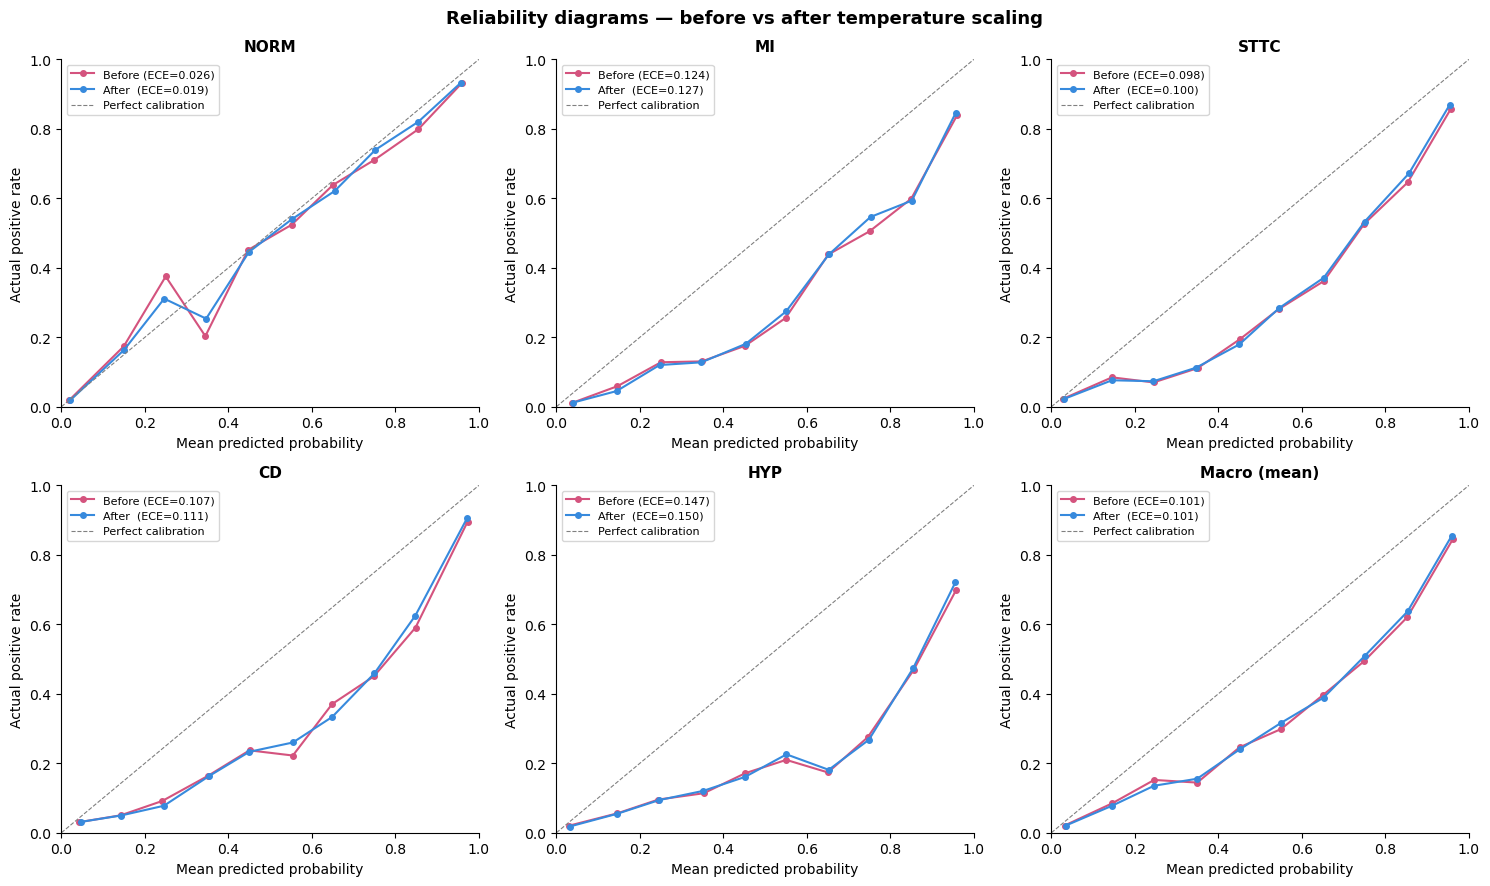

In [36]:

# ── AUC check — should be identical before and after ─────────────────────────
auc_before = roc_auc_score(all_labels, uncalibrated_probs, average='macro')
auc_after  = roc_auc_score(all_labels, calibrated_probs,   average='macro')
print(f"\nMacro AUC before: {auc_before:.4f}")
print(f"Macro AUC after:  {auc_after:.4f}")
print(f"AUC delta:        {auc_after - auc_before:.6f}  (should be ~0)")

# ── Plot reliability diagrams ─────────────────────────────────────────────────
fig = model_stats.plot_calibration_comparison(
    all_labels, uncalibrated_probs, calibrated_probs, CLASS_ORDER
)
plt.show()
# fig.savefig(ARTIFACTS / 'calibration_comparison.png',
#             dpi=150, bbox_inches='tight')
# print("Calibration comparison saved")

# # ── Save calibrated probabilities ─────────────────────────────────────────────
# np.save(ARTIFACTS / 'resnet_calibrated_probs.npy', calibrated_probs)
# print("Calibrated probabilities saved")

Fitting per-class temperature scaling...

Per-class optimal temperatures:
  NORM: T = 1.0965
  MI: T = 1.084
  STTC: T = 1.1214
  CD: T = 1.0
  HYP: T = 1.0646

ECE comparison — uncalibrated vs global T vs per-class T:
              Uncalibrated  Global T  Per-class T
NORM                0.0260    0.0193       0.0168
MI                  0.1244    0.1266       0.1276
STTC                0.0980    0.0998       0.1018
CD                  0.1074    0.1113       0.1074
HYP                 0.1470    0.1504       0.1508
Macro (mean)        0.1006    0.1015       0.1009

Macro AUC before: 0.9038
Macro AUC after:  0.9038
AUC delta:        0.000000  (should be ~0)


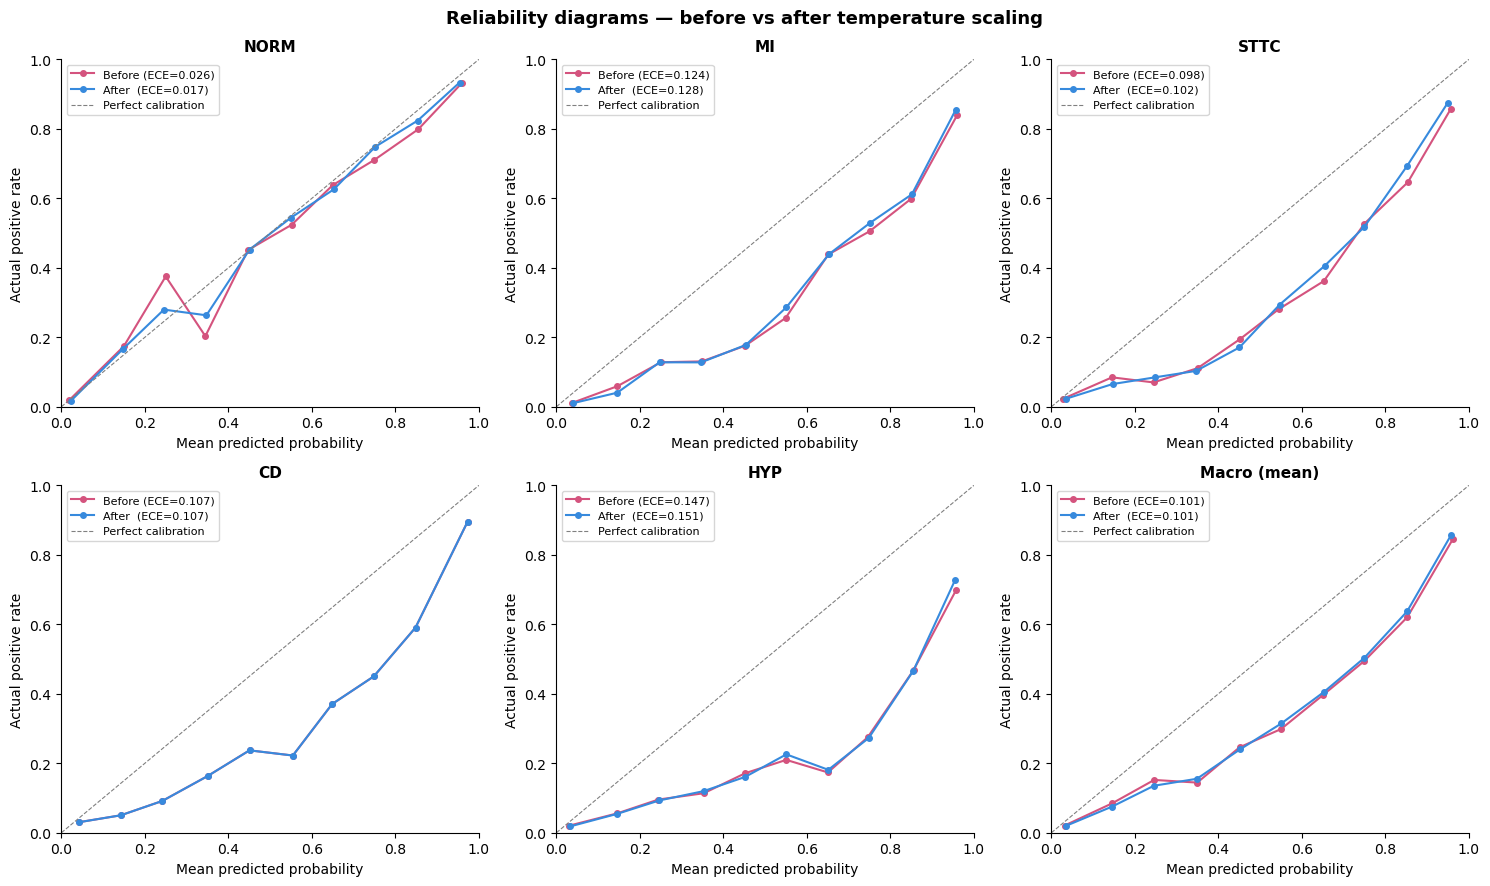

In [37]:
# ── Fit per-class temperature scaling ─────────────────────────────────────────
print("Fitting per-class temperature scaling...")
pc_ts = modeling.PerClassTemperatureScaling(n_classes=N_CLASSES, init_temp=1.0)
pc_temps = pc_ts.calibrate(val_loader, model, criterion, DEVICE)

print("\nPer-class optimal temperatures:")
for cls, t in zip(CLASS_ORDER, pc_temps):
    print(f"  {cls}: T = {t}")

# ── Get calibrated probabilities ──────────────────────────────────────────────
model.eval()
pc_ts.eval()
pc_ts.to(DEVICE)

all_logits = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(DEVICE)
        logits  = model(signals)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()

# Apply per-class temperature scaling
pc_calibrated_logits = pc_ts(all_logits.to(DEVICE)).cpu()
pc_calibrated_probs  = torch.sigmoid(pc_calibrated_logits).detach().numpy()
uncalibrated_probs   = torch.sigmoid(all_logits).detach().numpy()

# ── ECE comparison ────────────────────────────────────────────────────────────
print("\nECE comparison — uncalibrated vs global T vs per-class T:")
ece_comparison = pd.DataFrame({
    'Uncalibrated': [model_stats.compute_ece(all_labels[:, i], uncalibrated_probs[:, i])
                     for i in range(N_CLASSES)],
    'Global T':     [model_stats.compute_ece(all_labels[:, i], calibrated_probs[:, i])
                     for i in range(N_CLASSES)],
    'Per-class T':  [model_stats.compute_ece(all_labels[:, i], pc_calibrated_probs[:, i])
                     for i in range(N_CLASSES)],
}, index=CLASS_ORDER)

ece_comparison.loc['Macro (mean)'] = ece_comparison.mean().round(4)
print(ece_comparison)

# ── AUC check ─────────────────────────────────────────────────────────────────
auc_before = roc_auc_score(all_labels, uncalibrated_probs,  average='macro')
auc_after  = roc_auc_score(all_labels, pc_calibrated_probs, average='macro')
print(f"\nMacro AUC before: {auc_before:.4f}")
print(f"Macro AUC after:  {auc_after:.4f}")
print(f"AUC delta:        {auc_after - auc_before:.6f}  (should be ~0)")

# ── Plot reliability diagrams ─────────────────────────────────────────────────
fig = model_stats.plot_calibration_comparison(
    all_labels, uncalibrated_probs, pc_calibrated_probs, CLASS_ORDER
)
plt.show()
# fig.savefig(ARTIFACTS / 'calibration_per_class.png',
#             dpi=150, bbox_inches='tight')

# # ── Save ──────────────────────────────────────────────────────────────────────
# np.save(ARTIFACTS / 'resnet_pc_calibrated_probs.npy', pc_calibrated_probs)
# np.save(ARTIFACTS / 'pc_temperatures.npy', pc_temps)
# print("\nPer-class calibrated probabilities saved")

**Findings:**
1. Both global and per-class temperature scaling produced negligible improvement in macro ECE (0.1006 → 0.1009), indicating the miscalibration is not attributable to logit scaling. 
2. Analysis of per-class ECE reveals a strong inverse relationship between class prevalence and calibration quality — NORM (prevalence 44.5%, ECE=0.026) is substantially better calibrated than HYP (prevalence 12.4%, ECE=0.147). This suggests the miscalibration is driven by class imbalance rather than overconfidence, and may be better addressed through prevalence-weighted calibration or isotonic regression on a larger calibration set in future work.

**Decision:**

Use the uncalibrated probabilities the final test set output, applying a correction that does not help is worse than not applying it.

### Subgroup Analysis
Subgroup analysis evaluates whether your model performs consistently across different patient groups; sex and age. Required for our SAP and is one of the most important sections.

In [38]:
# Load test set metadata
test_df = df[df['split'] == 'test'].copy()
test_df.loc[test_df['age'] >= 89, 'age'] = 90 # Apply the age correction to people over 90
test_df['sex_label']  = test_df['sex'].map({0: 'Female', 1: 'Male'}) # Appply the maping of sex labels
# Create age groups/bins
test_df['age_group']  = pd.cut(
    test_df['age'],
    bins   = [0, 40, 60, 80, 100],
    labels = ['<40', '40-60', '60-80', '>80']
)

# Load artifact flags computed in EDA
test_artifact_flags = pd.read_csv(ARTIFACTS / 'test_artifact_flags.csv',
                                   index_col=0)
test_df = test_df.join(test_artifact_flags)

# Align final probs with test_df index
final_probs = np.load(ARTIFACTS / 'resnet_test_probs.npy')
test_labels = np.load(ARTIFACTS / 'resnet_test_labels.npy')

print(f"Test records:     {len(test_df):,}")
print(f"Sex distribution:\n{test_df['sex_label'].value_counts()}")
print(f"\nAge group distribution:\n{test_df['age_group'].value_counts().sort_index()}")
print(f"\nArtifact flags:\n{test_df['has_artifact'].value_counts()}")

Test records:     2,158
Sex distribution:
sex_label
Female    1110
Male      1048
Name: count, dtype: int64

Age group distribution:
age_group
<40      310
40-60    654
60-80    903
>80      291
Name: count, dtype: int64

Artifact flags:
has_artifact
False    1512
True      646
Name: count, dtype: int64


In [39]:

# ── Run ───────────────────────────────────────────────────────────────────────
print("Running subgroup analysis...")
subgroup_results = model_stats.run_subgroup_analysis(
    test_df, test_labels, final_probs, CLASS_ORDER
)

# ── Print results ─────────────────────────────────────────────────────────────
for subgroup, df_res in subgroup_results.items():
    print(f"\n── {subgroup} (N={int(df_res.loc['Macro (mean)', 'N']):,}) ──")
    print(df_res[['AUC', 'CI Lower', 'CI Upper', 'N_pos']].to_string())

# ── Build summary comparison table ───────────────────────────────────────────
print("\n── Macro AUC by subgroup ──────────────────────────────────────")
summary = pd.DataFrame({
    name: df['AUC']
    for name, df in subgroup_results.items()
}).loc['Macro (mean)']
print(summary)


Running subgroup analysis...

── Female (N=1,110) ──
                 AUC  CI Lower  CI Upper  N_pos
Class                                          
NORM          0.9432    0.9298    0.9547    516
MI            0.9218    0.9056    0.9367    297
STTC          0.9381    0.9210    0.9539    229
CD            0.9114    0.8914    0.9303    266
HYP           0.8379    0.8032    0.8722    135
Macro (mean)  0.9105    0.8902    0.9296   1443

── Male (N=1,048) ──
                 AUC  CI Lower  CI Upper  N_pos
Class                                          
NORM          0.9286    0.9144    0.9423    447
MI            0.9079    0.8892    0.9277    253
STTC          0.8990    0.8783    0.9178    292
CD            0.8984    0.8690    0.9247    230
HYP           0.8558    0.8199    0.8880    127
Macro (mean)  0.8979    0.8742    0.9201   1349

── <40 (N=310) ──
                 AUC  CI Lower  CI Upper  N_pos
Class                                          
NORM          0.8587    0.8029    0.9090  

In [40]:
import openpyxl

# ── Save all subgroup results to a single Excel file ─────────────────────────
excel_path = ARTIFACTS / 'subgroup_analysis.xlsx'

# with pd.ExcelWriter(excel_path, 'openpyxl') as writer:

#     # Summary sheet — macro AUC across all subgroups
#     summary_df = pd.DataFrame({
#         name: df['AUC']
#         for name, df in subgroup_results.items()
#     })
#     summary_df.to_excel(writer, sheet_name='Summary')

#     # One sheet per subgroup
#     for name, df_res in subgroup_results.items():
#         # Excel sheet names can't exceed 31 chars or contain special chars
#         safe_name = (name.replace('<', 'lt')
#                         .replace('>', 'gt')
#                         .replace('-', '_'))
#         df_res.to_excel(writer, sheet_name=safe_name)

print(f"Subgroup analysis saved to {excel_path}")
print(f"Sheets: Summary + {list(subgroup_results.keys())}")

Subgroup analysis saved to c:\Users\delga\OneDrive\Documents\personal_projects\DeepAF Automated Atrial Fibrillation Detection\ecg-ai-statistical-evaluation\artifacts\subgroup_analysis.xlsx
Sheets: Summary + ['Female', 'Male', '<40', '40-60', '60-80', '>80', 'Clean', 'Noisy']


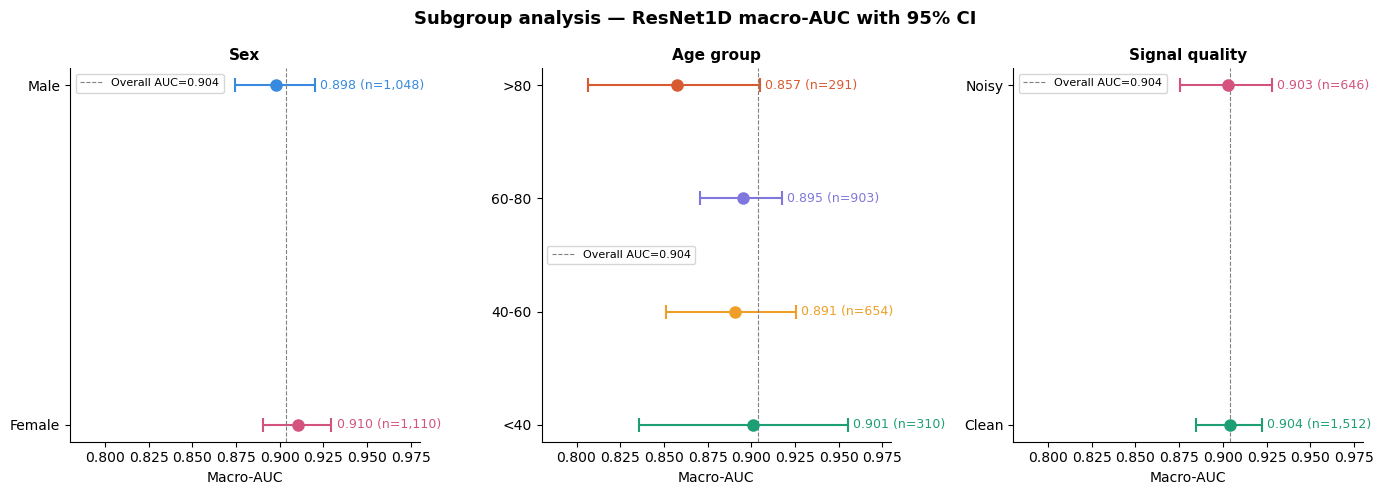

In [41]:
fig = model_stats.plot_subgroup_comparison(subgroup_results)
plt.show()
# fig.savefig(ARTIFACTS / 'subgroup_analysis.png', dpi=150, bbox_inches='tight')
# print("Subgroup plot saved")

Subgroup analysis revealed consistent performance across sex (Female: 0.911, Male: 0.898) and signal quality (Clean: 0.904, Noisy: 0.903), with overlapping confidence intervals indicating no statistically significant differences. 

Performance showed decline with age, with the oldest age group (>80 years) achieving the lowest macro-AUC (0.857, 95% CI: 0.807–0.905) compared to the overall test performance of 0.904. 

Results for the <40 age group should be interpreted cautiously due to sparse pathological class representation (MI n=7, HYP n=11). HYP remained the most challenging class across all subgroups.